# Complementary slackness contacts

This notebook generates `fig:dual-complementary-slackness-contacts`.  For the one-dimensional quadratic cost
$$
    c(x,y)=|x-y|^2,
$$
optimal dual potentials satisfy
$$
    f(x)+g(y) \leq c(x,y),
$$
and complementary slackness says that an optimal plan can charge only the contact set where equality holds.  In one dimension, the optimal plan is the graph of the monotone rearrangement
$$
    T = F_\beta^{-1}\circ F_\alpha.
$$
The figure plots the nonnegative slack
$$
    s(x,y)=c(x,y)-f(x)-g(y)
$$
as a continuous heatmap for two examples: a single-Gaussian transport and a two-Gaussian-mixture transport.  The violet curve is the transported contact set $(x,T(x))$; no additional contact markers are drawn, so the graph remains visually light.


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate figure_style.py")

sys.path.insert(0, str(FIGROOT.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as DisplayImage
from IPython.display import display
from matplotlib import patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

from figure_style import (
    BACKGROUND,
    BLUE,
    GRAY,
    RED,
    VIOLET,
    box_axes,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "dual-complementary-slackness-contacts"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = FIGROOT / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)


## Smooth data and exact monotone maps

The left panel uses a single Gaussian transported to another Gaussian, where the contact set is almost the simplest possible one-dimensional quadratic OT graph.  The right panel uses two Gaussian mixtures, so the same complementary-slackness mechanism produces a visibly curved valley.

Both panels are computed at the continuum level on a fine grid: the map is recovered from numerical quantiles, then the potential derivative
$$
    f'(x)=\partial_x c(x,T(x)) = 2(x-T(x))
$$
is integrated.  The second potential is the hard `c`-transform $g=f^c$, which enforces the dual feasibility inequality on the grid.  A final diagnostic evaluates the slack along each quantile graph to check that the displayed violet curve is a numerical contact set.


In [2]:
grid = np.linspace(-3.45, 3.45, 980)
dx = grid[1] - grid[0]


def gaussian_mixture_density(x, weights, means, stds):
    x = np.asarray(x)
    density = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        density += w * np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    density /= np.trapezoid(density, x)
    return density


def cdf_from_density(density):
    increments = 0.5 * (density[:-1] + density[1:]) * np.diff(grid)
    cdf = np.r_[0.0, np.cumsum(increments)]
    cdf /= cdf[-1]
    # Numerical monotonicity protects inverse interpolation in the far tails.
    return np.maximum.accumulate(cdf)


def cumulative_trapezoid(values):
    increments = 0.5 * (values[:-1] + values[1:]) * np.diff(grid)
    return np.r_[0.0, np.cumsum(increments)]


def build_contact_example(alpha_params, beta_params, *, xlim, ylim):
    alpha = gaussian_mixture_density(grid, **alpha_params)
    beta = gaussian_mixture_density(grid, **beta_params)

    Fa = cdf_from_density(alpha)
    Fb = cdf_from_density(beta)
    levels = np.clip(Fa, 2e-5, 1 - 2e-5)
    T = np.interp(levels, Fb, grid)

    fp = 2.0 * (grid - T)
    f = cumulative_trapezoid(fp)
    f -= np.trapezoid(f * alpha, grid)

    C = (grid[:, None] - grid[None, :]) ** 2
    g = np.min(C - f[:, None], axis=0)

    slack = C - f[:, None] - g[None, :]
    slack_display = np.maximum(slack, 0.0)

    beta_T = np.interp(T, grid, beta)
    contact_mask = (
        (grid >= xlim[0])
        & (grid <= xlim[1])
        & (T >= ylim[0])
        & (T <= ylim[1])
        & (alpha > 0.014 * alpha.max())
        & (beta_T > 0.014 * beta.max())
    )
    contact_residual = (grid - T) ** 2 - f - np.interp(T, grid, g)

    x_visible = (grid >= xlim[0]) & (grid <= xlim[1])
    y_visible = (grid >= ylim[0]) & (grid <= ylim[1])
    visible_slack = slack_display[np.ix_(x_visible, y_visible)]
    positive_visible = visible_slack[visible_slack > 1e-9]
    vmax = np.quantile(visible_slack, 0.90)
    contour_levels = np.quantile(positive_visible, [0.035, 0.09, 0.18, 0.34, 0.56, 0.78])

    return {
        "alpha": alpha,
        "beta": beta,
        "Fa": Fa,
        "Fb": Fb,
        "T": T,
        "slack": slack,
        "slack_display": slack_display,
        "contact_mask": contact_mask,
        "contact_residual": contact_residual,
        "xlim": xlim,
        "ylim": ylim,
        "vmax": vmax,
        "contour_levels": contour_levels,
        "x_visible": x_visible,
        "y_visible": y_visible,
    }


examples = [
    build_contact_example(
        alpha_params=dict(weights=[1.0], means=[-0.95], stds=[0.50]),
        beta_params=dict(weights=[1.0], means=[0.78], stds=[0.36]),
        xlim=(-2.45, 1.05),
        ylim=(-0.35, 1.90),
    ),
    build_contact_example(
        alpha_params=dict(weights=[0.44, 0.56], means=[-1.55, 0.72], stds=[0.31, 0.42]),
        beta_params=dict(weights=[0.52, 0.48], means=[-0.62, 1.58], stds=[0.25, 0.36]),
        xlim=(-2.55, 1.55),
        ylim=(-1.25, 2.35),
    ),
]

for name, example in zip(["Gaussian", "two-mixture"], examples):
    mask = example["contact_mask"]
    residual = np.abs(example["contact_residual"][mask])
    print(f"{name}: minimum grid slack = {example['slack'].min():.3e}")
    print(f"{name}: median |slack| on drawn contact graph = {np.median(residual):.3e}")
    print(f"{name}: max |slack| on drawn contact graph = {np.max(residual):.3e}")


Gaussian: minimum grid slack = 0.000e+00
Gaussian: median |slack| on drawn contact graph = 6.895e-07
Gaussian: max |slack| on drawn contact graph = 1.488e-06
two-mixture: minimum grid slack = 0.000e+00
two-mixture: median |slack| on drawn contact graph = 4.369e-06
two-mixture: max |slack| on drawn contact graph = 4.969e-04


## Exported panel

Each small display shows the slack $s(x,y)$.  Darker blue means larger strict slack in the dual inequality, while the pale valley is the near-zero contact locus.  The violet curve marks the graph of the monotone transport map.  Red and blue marginal strips identify the source and target densities.


In [3]:
slack_cmap = LinearSegmentedColormap.from_list(
    "ot4ml_slack",
    ["#fffaf0", "#efe4f0", "#ccdff1", "#80a7cf", "#234b82"],
)


def draw_contact_panel(fig, outer_spec, example):
    gs = outer_spec.subgridspec(
        2,
        2,
        width_ratios=[1.0, 0.15],
        height_ratios=[0.16, 1.0],
        wspace=0.032,
        hspace=0.032,
    )
    ax_top = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

    alpha = example["alpha"]
    beta = example["beta"]
    T = example["T"]
    slack_display = example["slack_display"]
    xlim = example["xlim"]
    ylim = example["ylim"]

    ax.imshow(
        np.clip(slack_display.T, 0.0, example["vmax"]),
        origin="lower",
        extent=[grid.min(), grid.max(), grid.min(), grid.max()],
        cmap=slack_cmap,
        vmin=0.0,
        vmax=example["vmax"],
        interpolation="bilinear",
        aspect="auto",
    )
    ax.contour(
        grid,
        grid,
        slack_display.T,
        levels=example["contour_levels"],
        colors="#334155",
        linewidths=0.24,
        alpha=0.32,
    )

    # A white halo makes the contact line readable on both pale and blue regions.
    halo = [pe.Stroke(linewidth=2.55, foreground="white", alpha=0.92), pe.Normal()]
    mask = example["contact_mask"]
    ax.plot(
        grid[mask],
        T[mask],
        color=VIOLET,
        lw=1.38,
        solid_capstyle="round",
        path_effects=halo,
        zorder=5,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$x$", labelpad=0.8)
    ax.set_ylabel(r"$y$", labelpad=0.8)
    ax.tick_params(labelbottom=False, labelleft=False, length=0)
    box_axes(ax)

    ax_top.fill_between(grid, 0, alpha, color=RED, alpha=0.25, linewidth=0)
    ax_top.plot(grid, alpha, color=RED, lw=0.78)
    ax_top.set_xlim(*xlim)
    ax_top.set_ylim(0, 1.08 * alpha[example["x_visible"]].max())
    ax_top.tick_params(labelbottom=False, labelleft=False, length=0)
    ax_top.set_facecolor(BACKGROUND)
    box_axes(ax_top)

    ax_right.fill_betweenx(grid, 0, beta, color=BLUE, alpha=0.25, linewidth=0)
    ax_right.plot(beta, grid, color=BLUE, lw=0.78)
    ax_right.set_ylim(*ylim)
    ax_right.set_xlim(0, 1.08 * beta[example["y_visible"]].max())
    ax_right.tick_params(labelbottom=False, labelleft=False, length=0)
    ax_right.set_facecolor(BACKGROUND)
    box_axes(ax_right)


fig = plt.figure(figsize=(5.18, 2.25))
outer = fig.add_gridspec(1, 2, wspace=0.20)
for j, example in enumerate(examples):
    draw_contact_panel(fig, outer[j], example)

save_pdf(fig, OUT / "contacts.pdf", pad_inches=0.026)
fig.savefig(THUMB_OUT / f"{NAME}.png", dpi=220, bbox_inches="tight", pad_inches=0.022)
plt.close(fig)

shutil.copyfile(OUT / "contacts.pdf", ARXIV_OUT / f"{NAME}--contacts.pdf")
print(f"Wrote {OUT / 'contacts.pdf'}")
print(f"Wrote {ARXIV_OUT / (NAME + '--contacts.pdf')}")
print(f"Wrote {THUMB_OUT / (NAME + '.png')}")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/dual-complementary-slackness-contacts/contacts.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/arxiv/figures/dual-complementary-slackness-contacts--contacts.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/dual-complementary-slackness-contacts.png


## Gallery preview

The PDF used in the book is title-free.  The PNG below is the notebook-gallery thumbnail regenerated from the same drawing code.

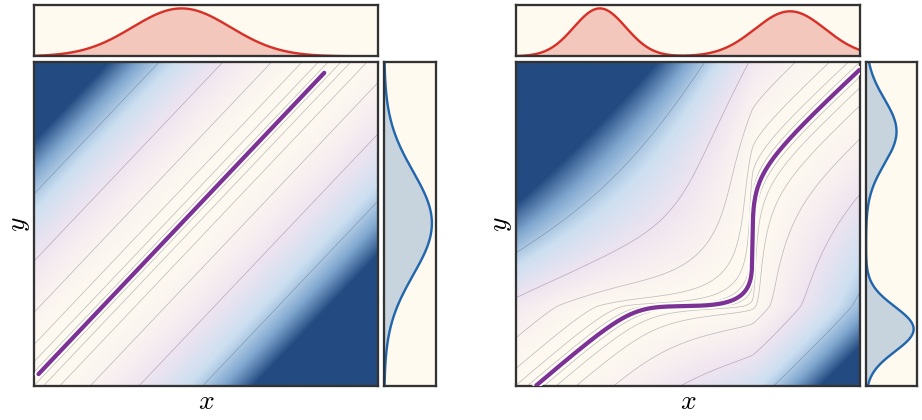

In [4]:
display(DisplayImage(filename=str(THUMB_OUT / f"{NAME}.png"), width=520))
